In [1]:
import openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import BorderlineSMOTE


###  Ucitavanje skupa podataka OpenML platforme (ID 1161)

In [2]:
dataset = openml.datasets.get_dataset(1161)
X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format='dataframe',
    target=dataset.default_target_attribute
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

def save_split(X_tr, X_te, y_tr, y_te, base_name, columns=None):
    cols = columns

    y_tr_v = pd.Series(y_tr).reset_index(drop=True)
    y_te_v = pd.Series(y_te).reset_index(drop=True)

    pd.DataFrame(X_tr, columns=cols).reset_index(drop=True).assign(target=y_tr_v).to_csv(
        f'data/{base_name}_train.csv', index=False
    )
    pd.DataFrame(X_te, columns=cols).reset_index(drop=True).assign(target=y_te_v).to_csv(
        f'data/{base_name}_test.csv', index=False
    )

save_split(X_train, X_test, y_train, y_test, 'data_raw', X_train.columns)

print(f'Ukupno X shape: {X.shape} \n')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Imamo mnogo vise gena (>10^4) nego uzoraka (>10^3) - prokletstvo dimenzionalnosti \n')


Ukupno X shape: (1545, 10935) 

Train: (1158, 10935), Test: (387, 10935)
Imamo mnogo vise gena (>10^4) nego uzoraka (>10^3) - prokletstvo dimenzionalnosti 



### Analiziramo distribuciju klasa

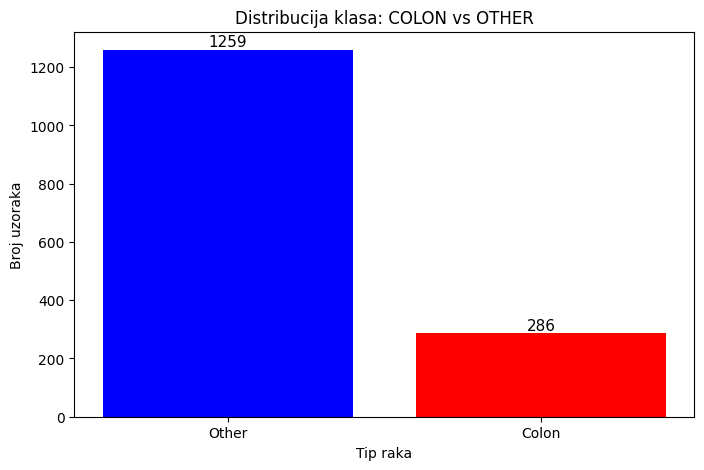

In [3]:
class_counts = y.value_counts()
labels = class_counts.index.tolist()  # labels daje ['Colon', 'Other']
values = class_counts.values.tolist() # values daje broj koliko cega

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['blue', 'red'])
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.001,
            str(val), ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Tip raka')
ax.set_ylabel('Broj uzoraka')
ax.set_title('Distribucija klasa: COLON vs OTHER')
plt.show()

In [4]:
print('Nebalansiran skup podataka:')
imbalance_ratio = class_counts['Other'] / class_counts['Colon']
print(f'\t tratio OTHER:COLON = {imbalance_ratio:.2f}:1')
print(f'\t Procenat COLON: {class_counts["Colon"]/len(y)*100:.1f}%')
print(f'\t Procenat OTHER: {class_counts["Other"]/len(y)*100:.1f}%')


Nebalansiran skup podataka:
	 tratio OTHER:COLON = 4.40:1
	 Procenat COLON: 18.5%
	 Procenat OTHER: 81.5%


### Provera nedostajucih vrednosti

In [5]:
print('Skeniranje nedostajucih vrednosti:')
print(f'\t X - ima li NaN: {X.isna().any().any()}')
print(f'\t y - ima li NaN: {y.isna().any().any()}')

Skeniranje nedostajucih vrednosti:
	 X - ima li NaN: False
	 y - ima li NaN: False


### Detekcija autlajera. Za prvih 100 gena racunamo binarnu mapu autlajera (po IQR pravilu) i prikazujemo je kao heat-mapu. Zatim za 5 gena sa **najvecom varijansom** crtamo box-plot

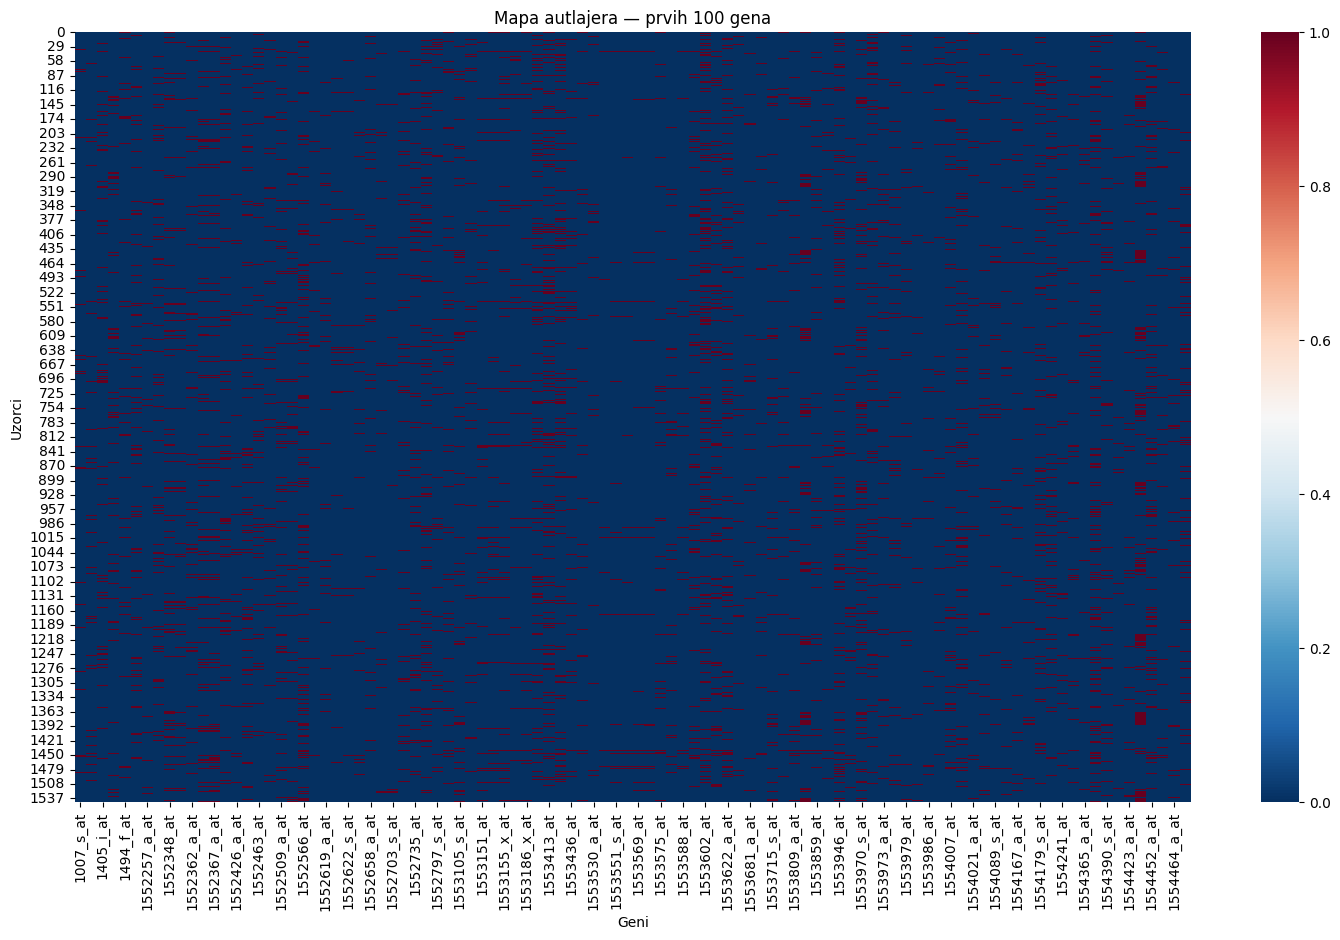

In [6]:
outlier_matrix = pd.DataFrame(index=X.index, columns=X.columns[:100])

for col in X.columns[:100]:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_matrix[col] = ((X[col] < lower_bound) | (X[col] > upper_bound)).astype(int)

plt.figure(figsize=(18, 10))
sns.heatmap(outlier_matrix, cmap='RdBu_r')
plt.title('Mapa autlajera - prvih 100 gena')
plt.xlabel('Geni')
plt.ylabel('Uzorci')
plt.show()

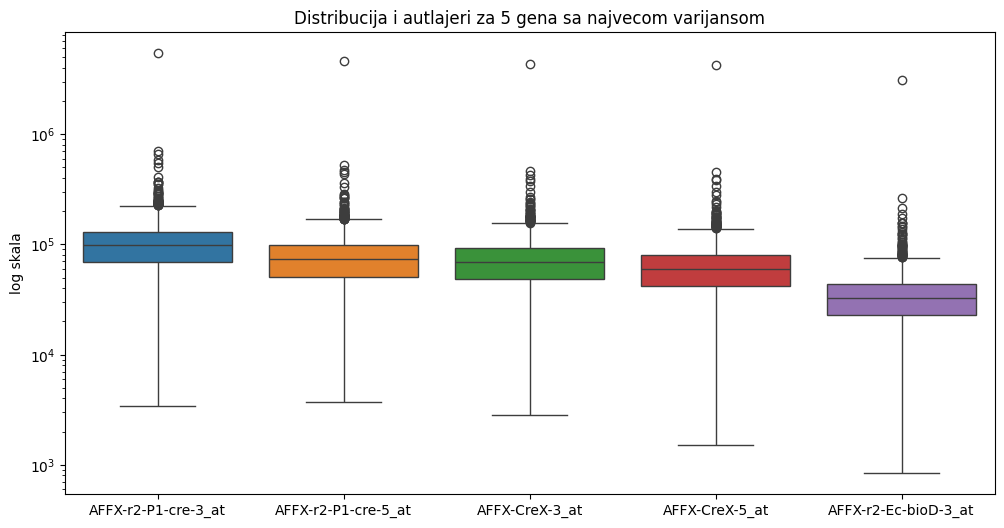

In [7]:
variances = np.var(X, axis=0)
sorted_indices = np.argsort(variances)[::-1]
top_var_genes = sorted_indices[:5]

plt.figure(figsize=(12, 6))
sns.boxplot(data=X.iloc[:, top_var_genes])
plt.title('Distribucija i autlajeri za 5 gena sa najvecom varijansom')
plt.ylabel('log skala')
plt.yscale('log')
plt.show()

### Standardizacija podataka

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)        

save_split(X_train_scaled, X_test_scaled, y_train, y_test, 'data_scaled', columns=X.columns)

# Za vizuelizacije u narednim celijama
X_scaled = scaler.transform(X)


### PCA - gradi nove ortogonalne komponente sortirane po varijansi

Komponente za 70% varijanse: 122
Komponente za 80% varijanse: 237


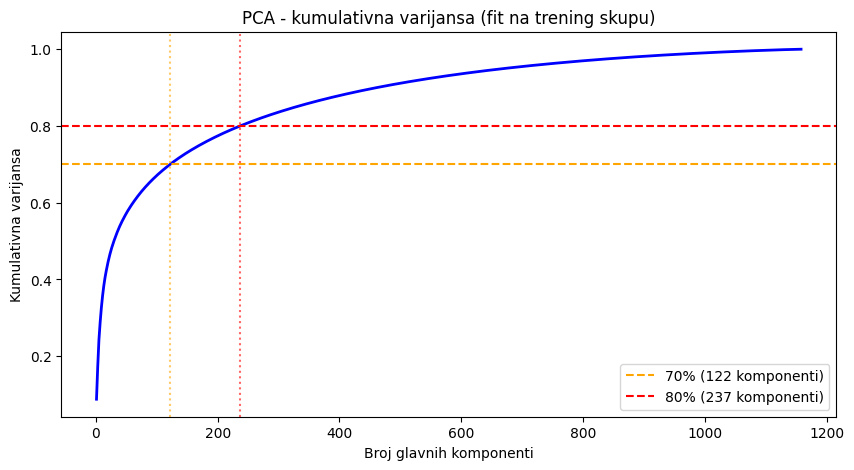

In [9]:
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_70 = int(np.argmax(cumulative_variance >= 0.70)) + 1
n_80 = int(np.argmax(cumulative_variance >= 0.80)) + 1
print(f'Komponente za 70% varijanse: {n_70}')
print(f'Komponente za 80% varijanse: {n_80}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
ax.axhline(y=0.70, color='orange', linestyle='--', label=f'70% ({n_70} komponenti)')
ax.axhline(y=0.80, color='red', linestyle='--', label=f'80% ({n_80} komponenti)')
ax.axvline(x=n_70, color='orange', linestyle=':', alpha=0.6)
ax.axvline(x=n_80, color='red', linestyle=':', alpha=0.6)
ax.set_xlabel('Broj glavnih komponenti')
ax.set_ylabel('Kumulativna varijansa')
ax.set_title('PCA - kumulativna varijansa (fit na trening skupu)')
ax.legend()
plt.show()


###  PCA — 2D vizuelizacija. Tacke su obojene prema klasi: crveno = ***Colon***, plavo = ***Other***

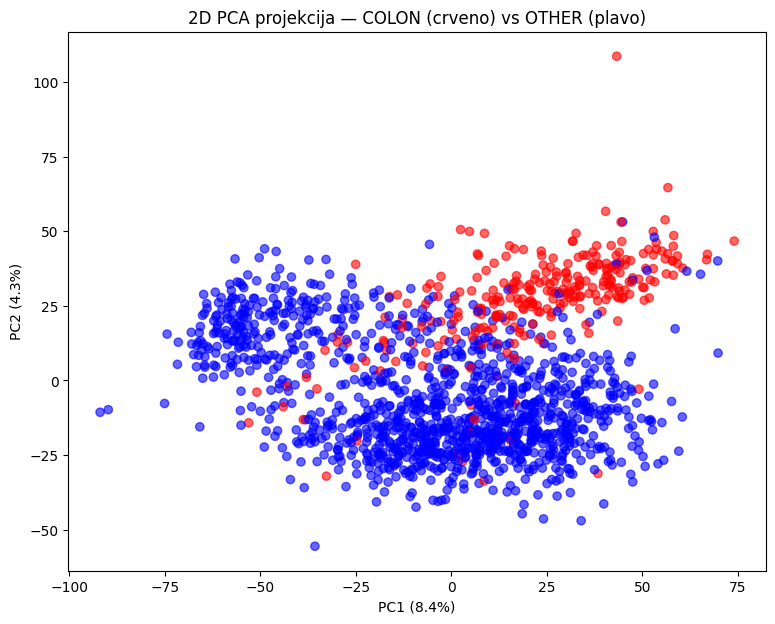

In [10]:
def pca_transform_graph(X, y, components, graph=True):
    pca = PCA(n_components=components)
    X_pca = pca.fit_transform(X)
    colors = ['red' if label == 'Colon' else 'blue' for label in y]

    if graph:
        if components == 2:
            plt.figure(figsize=(9, 7))
            plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6)
            plt.title('2D PCA projekcija — COLON (crveno) vs OTHER (plavo)')
            plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            plt.show()
        elif components == 3:
            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.6)
            ax.set_title('3D PCA projekcija — COLON (crveno) vs OTHER (plavo)')
            ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
            ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
            ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
            plt.show()
    return X_pca, y, pca

X_pca2d, _, _ = pca_transform_graph(X_scaled, y, 2)

### PCA - 3D vizuelizacija

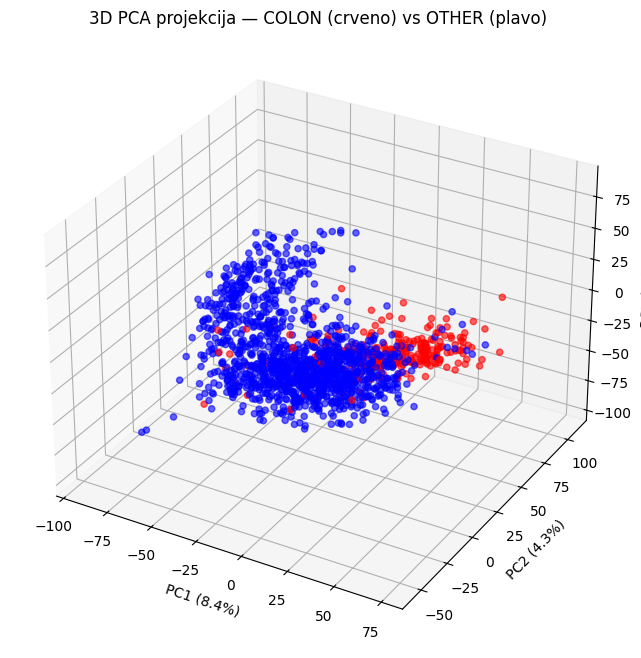


    Klasa Colon formira relativno kompaktan klaster, dok je klasa Other disperznija
    i sastoji se od vise podgrupa. postoji i odredjeni
    stepen separabilnosti 


In [11]:
X_pca3d, _, _ = pca_transform_graph(X_scaled, y, 3)

print('''
    Klasa Colon formira relativno kompaktan klaster, dok je klasa Other disperznija
    i sastoji se od vise podgrupa. postoji i odredjeni
    stepen separabilnosti '''
     )

### t-SNE projekcija je nelinearna tehnika redukcije koja čuva lokalnu strukturu

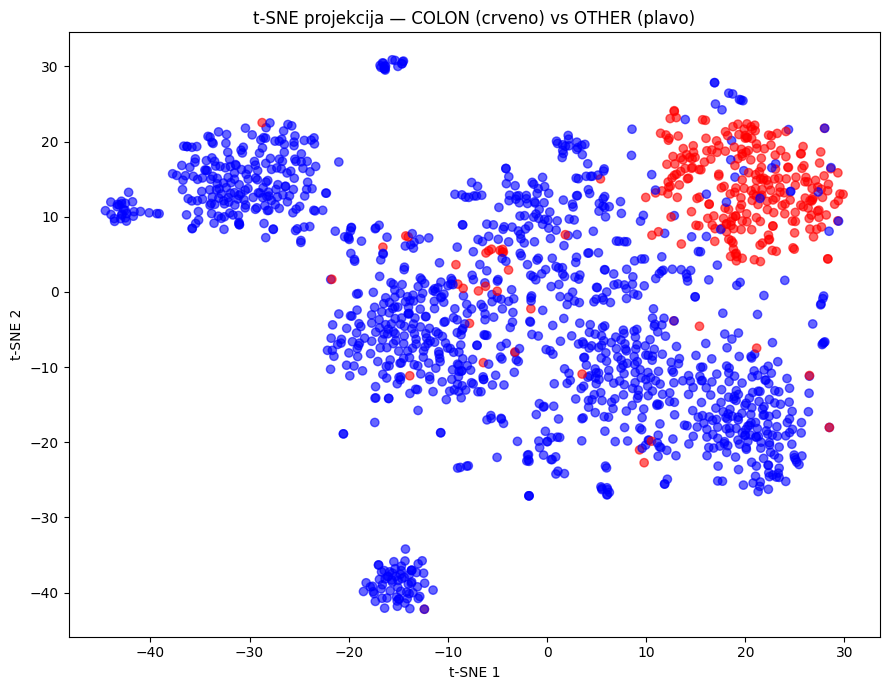


    t-SNE projekcija ne pokazuje znatno bolje razdvajanje klasa od PCA, sto znaci
    da podaci nemaju izrazenu nelinearnu strukturu i da se klase delimicno preklapaju.


In [12]:
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)

colors = ['red' if label == 'Colon' else 'blue' for label in y]
plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6)
plt.title('t-SNE projekcija — COLON (crveno) vs OTHER (plavo)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

print('''
    t-SNE projekcija ne pokazuje znatno bolje razdvajanje klasa od PCA, sto znaci
    da podaci nemaju izrazenu nelinearnu strukturu i da se klase delimicno preklapaju.'''
     )

### Selekcija atributa - `SelectKBest` (F-test)

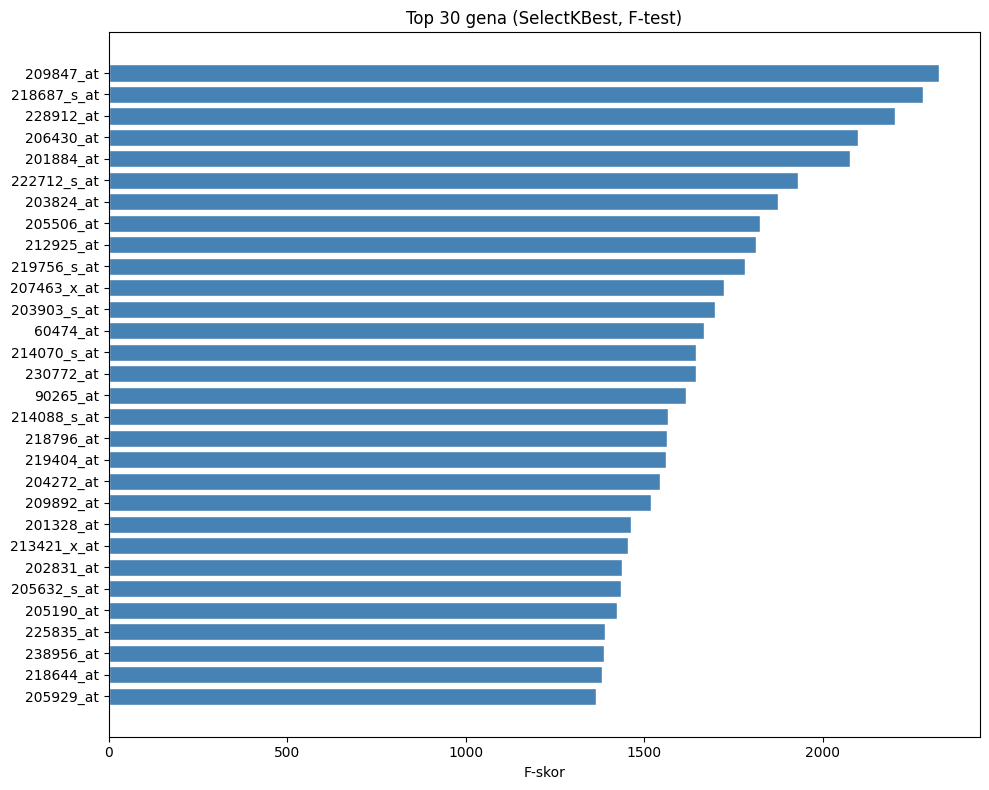

In [13]:
selector = SelectKBest(score_func=f_classif, k=30)
selector.fit(X_scaled, y)

scores = selector.scores_
top_idx = np.argsort(scores)[-30:]
top_features = X.columns[top_idx]
top_scores = scores[top_idx]

sorted_idx = np.argsort(top_scores)
top_features = top_features[sorted_idx]
top_scores = top_scores[sorted_idx]

plt.figure(figsize=(10, 8))
plt.barh(top_features, top_scores, color='steelblue', edgecolor='white')
plt.xlabel('F-skor')
plt.title('Top 30 gena (SelectKBest, F-test)')
plt.tight_layout()
plt.show()

### Korelaciona matrica top gena

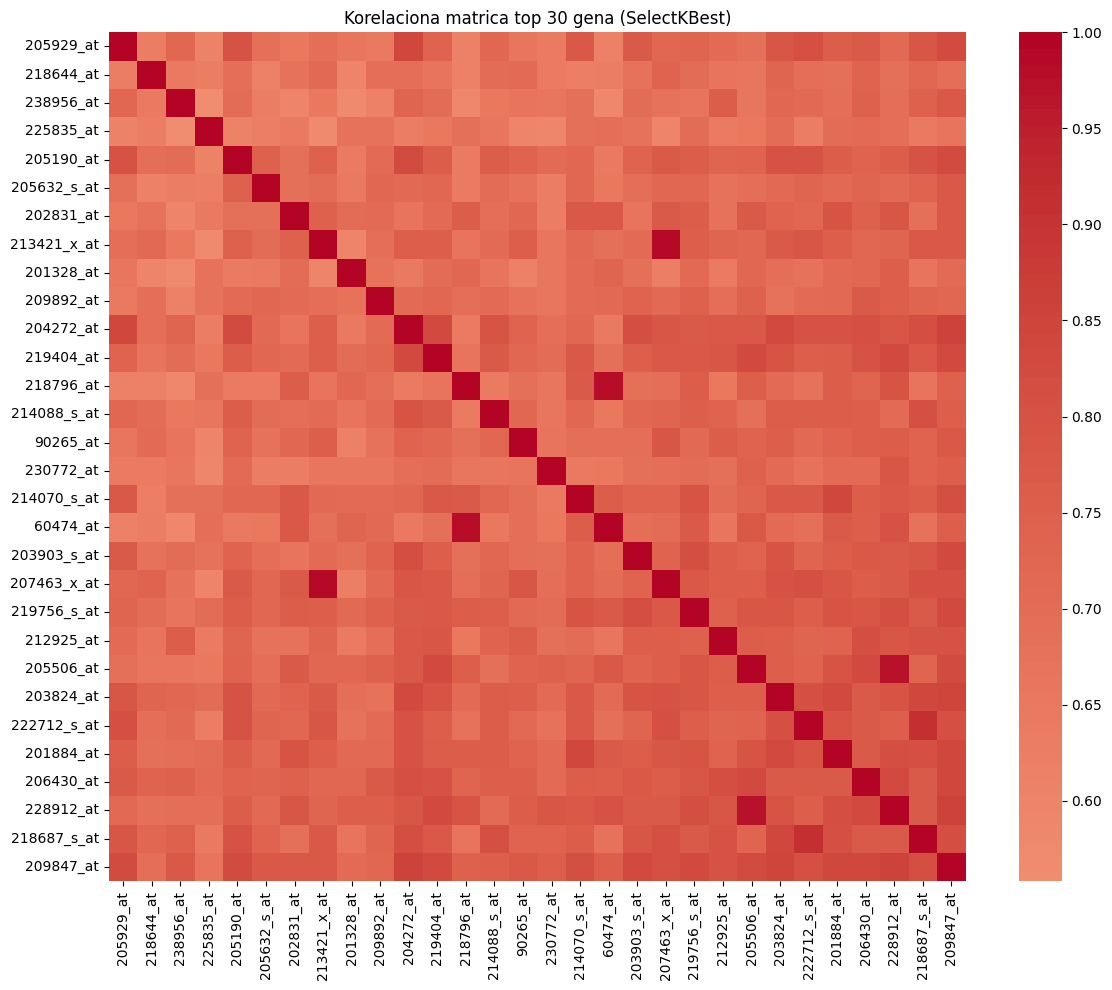

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.DataFrame(X_scaled, columns=X.columns)[top_features].corr(),
    annot=False, cmap='coolwarm', center=0
)
plt.title('Korelaciona matrica top 30 gena (SelectKBest)')
plt.tight_layout()
plt.show()

### SMOTE (bordered) oversampling

In [15]:
def smote_train_save(X_tr, X_te, y_tr, y_te, base_name, columns=None):
    sm = BorderlineSMOTE(random_state=42, kind='borderline-1', k_neighbors=3)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)  
    save_split(X_tr_res, X_te, y_tr_res, y_te, base_name, columns=columns)

smote_train_save(X_train_scaled, X_test_scaled, y_train, y_test, 'data_smote', columns=X.columns)


###  Generisanje top-K skupova za SMOTE. Generisacemo skup koji sadrzi samo top-K najinformativnijih gena (po F-testu) i nakon toga primenjujemo SMOTE.

In [16]:
def featureselect_smote_save(X_tr_raw, X_te_raw, y_tr, y_te, k, base_name):
    selector = SelectKBest(f_classif, k=k)
    X_tr_sel = selector.fit_transform(X_tr_raw, y_tr)   
    X_te_sel = selector.transform(X_te_raw)              
    selected_cols = X_tr_raw.columns[selector.get_support()]

    sm = BorderlineSMOTE(random_state=42, kind='borderline-1', k_neighbors=5)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr_sel, y_tr) 

    print(f'k={k:>3}: shape train={X_tr_res.shape}, shape test={X_te_sel.shape}')
    save_split(X_tr_res, X_te_sel, y_tr_res, y_te, base_name, columns=selected_cols)

for k in [20, 30, 40, 50, 100, 200]:
    featureselect_smote_save(X_train, X_test, y_train, y_test, k, f'data_top{k}_genes_smote')


k= 20: shape train=(1888, 20), shape test=(387, 20)
k= 30: shape train=(1888, 30), shape test=(387, 30)
k= 40: shape train=(1888, 40), shape test=(387, 40)
k= 50: shape train=(1888, 50), shape test=(387, 50)
k=100: shape train=(1888, 100), shape test=(387, 100)
k=200: shape train=(1888, 200), shape test=(387, 200)


### Generisanje PCA skupova (sa i bez SMOTE)

In [20]:
def pca_smote_save(X_tr, X_te, y_tr, y_te, base_name,
                  components=None, variance_threshold=0.8, smote_flag=True):
    if components is None:
        pca_temp = PCA().fit(X_tr)
        cumvar = np.cumsum(pca_temp.explained_variance_ratio_)
        components = int(np.where(cumvar >= variance_threshold)[0][0]) + 1
        print(f'\t Izabrano {components} komponenti za {variance_threshold*100:.0f}% varijanse')

    pca = PCA(n_components=components)
    X_tr_pca = pca.fit_transform(X_tr)   
    X_te_pca = pca.transform(X_te)      
    print(f'\t Varijansa: {sum(pca.explained_variance_ratio_)*100:.1f}%')

    if smote_flag:
        sm = BorderlineSMOTE(random_state=42, kind='borderline-1')
        X_tr_pca, y_tr = sm.fit_resample(X_tr_pca, y_tr)

    pca_columns = [f'PC{i+1}' for i in range(X_tr_pca.shape[1])]
    save_split(X_tr_pca, X_te_pca, y_tr, y_te, base_name, columns=pca_columns)


In [21]:
print('PCA 70% bez SMOTE:')
pca_smote_save(X_train_scaled, X_test_scaled, y_train, y_test, 'data_pca70',
               variance_threshold=0.7, smote_flag=False)

print('\nPCA 80% bez SMOTE:')
pca_smote_save(X_train_scaled, X_test_scaled, y_train, y_test, 'data_pca80',
               variance_threshold=0.8, smote_flag=False)

print('\nPCA 70% + SMOTE:')
pca_smote_save(X_train_scaled, X_test_scaled, y_train, y_test, 'data_pca70_smoted',
               variance_threshold=0.7, smote_flag=True)

print('\nPCA 80% + SMOTE:')
pca_smote_save(X_train_scaled, X_test_scaled, y_train, y_test, 'data_pca80_smoted',
               variance_threshold=0.8, smote_flag=True)


PCA 70% bez SMOTE:
	 Izabrano 122 komponenti za 70% varijanse
	 Varijansa: 69.8%

PCA 80% bez SMOTE:
	 Izabrano 237 komponenti za 80% varijanse
	 Varijansa: 79.8%

PCA 70% + SMOTE:
	 Izabrano 122 komponenti za 70% varijanse
	 Varijansa: 69.8%

PCA 80% + SMOTE:
	 Izabrano 237 komponenti za 80% varijanse
	 Varijansa: 79.8%


## Rezime

In [22]:
print('=== REZIME PRIPREME ===')
print(f'Sirov skup:                {X.shape}')
print(f'Klase:                     {dict(class_counts)}')
print(f'Nebalansiranost:           {imbalance_ratio:.2f}:1')
print(f'Train size:                {X_train.shape[0]}')
print(f'Test  size:                {X_test.shape[0]}')
print(f'PCA komponenti (70%):      {n_70}')
print(f'PCA komponenti (80%):      {n_80}')
print()
print('Sacuvani fajlovi u data/ (svaki kao _train.csv + _test.csv par):')
import os
for f in sorted(os.listdir('data')):
    if f.endswith('.csv'):
        size_mb = os.path.getsize(f'data/{f}') / 1e6
        print(f'  {f:<45} ({size_mb:>7.2f} MB)')


=== REZIME PRIPREME ===
Sirov skup:                (1545, 10935)
Klase:                     {'Other': np.int64(1259), 'Colon': np.int64(286)}
Nebalansiranost:           4.40:1
Train size:                1158
Test  size:                387
PCA komponenti (70%):      122
PCA komponenti (80%):      237

Sacuvani fajlovi u data/ (svaki kao _train.csv + _test.csv par):
  data_pca70_smoted_test.csv                    (   0.91 MB)
  data_pca70_smoted_train.csv                   (   4.41 MB)
  data_pca70_test.csv                           (   0.91 MB)
  data_pca70_train.csv                          (   2.70 MB)
  data_pca80_smoted_test.csv                    (   1.77 MB)
  data_pca80_smoted_train.csv                   (   8.60 MB)
  data_pca80_test.csv                           (   1.77 MB)
  data_pca80_train.csv                          (   5.27 MB)
  data_raw_test.csv                             (  28.07 MB)
  data_raw_train.csv                            (  83.71 MB)
  data_scaled_test.csv 